# 01 — Dataset Audit (Gate 1)
Goal: verify the downloaded RealWaste copy before any split or training.

**Do not train models in this notebook.**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_ROOT = Path('/content/drive/MyDrive/Deep Learning - RealWaste/01_Dataset/RealWaste')
AUDIT_OUT = Path('/content/drive/MyDrive/Deep Learning - RealWaste/04_Results/dataset_audit')
AUDIT_OUT.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
print('Dataset root:', DATASET_ROOT)
print('Exists:', DATASET_ROOT.exists())


Dataset root: /content/drive/MyDrive/Deep Learning - RealWaste/01_Dataset/RealWaste
Exists: True


In [3]:
class_dirs = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])
print('Number of class folders:', len(class_dirs))
for p in class_dirs:
    print('-', p.name)


Number of class folders: 9
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation


In [4]:
records = []
metadata = []
corrupted = []

for class_dir in class_dirs:
    files = [
        p for p in class_dir.rglob('*')
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]
    records.append({
        'class_name': class_dir.name,
        'num_images_found': len(files)
    })

    for path in files:
        try:
            # Verify the image file is readable
            with Image.open(path) as img:
                img.verify()

            # Re-open after verify() to read metadata safely
            with Image.open(path) as img:
                w, h = img.size
                metadata.append({
                    'filepath': str(path),
                    'class_name': class_dir.name,
                    'width': w,
                    'height': h,
                    'mode': img.mode,
                    'extension': path.suffix.lower(),
                })
        except Exception as e:
            corrupted.append({
                'filepath': str(path),
                'class_name': class_dir.name,
                'error': str(e)
            })

df_counts = pd.DataFrame(records)
df_meta = pd.DataFrame(metadata)
df_corrupt = pd.DataFrame(corrupted)

print(df_counts.to_string(index=False))
print('\nValid images:', len(df_meta))
print('Corrupted images:', len(df_corrupt))


         class_name  num_images_found
          Cardboard               461
      Food Organics               411
              Glass               420
              Metal               790
Miscellaneous Trash               495
              Paper               500
            Plastic               921
      Textile Trash               318
         Vegetation               436

Valid images: 4752
Corrupted images: 0


In [5]:
print('Modes:')
print(df_meta['mode'].value_counts(dropna=False))

print('\nExtensions:')
print(df_meta['extension'].value_counts(dropna=False))

print('\nMost common dimensions:')
print(
    df_meta.groupby(['width', 'height'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

valid_counts = df_meta.groupby('class_name').size().sort_values(ascending=False)
print('\nValid class counts:')
print(valid_counts)

if len(valid_counts) > 0 and valid_counts.min() > 0:
    print('\nLargest/smallest ratio:', round(valid_counts.max() / valid_counts.min(), 2))


Modes:
mode
RGB    4752
Name: count, dtype: int64

Extensions:
extension
.jpg    4752
Name: count, dtype: int64

Most common dimensions:
width  height
524    524       4752
dtype: int64

Valid class counts:
class_name
Plastic                921
Metal                  790
Paper                  500
Miscellaneous Trash    495
Cardboard              461
Vegetation             436
Glass                  420
Food Organics          411
Textile Trash          318
dtype: int64

Largest/smallest ratio: 2.9


In [6]:
# Save audit tables
df_counts.to_csv(AUDIT_OUT / 'folder_image_counts.csv', index=False)
df_meta.to_csv(AUDIT_OUT / 'image_metadata.csv', index=False)
df_corrupt.to_csv(AUDIT_OUT / 'corrupted_images.csv', index=False)
valid_counts.rename('valid_images').reset_index().to_csv(
    AUDIT_OUT / 'class_distribution.csv', index=False
)
print('Saved audit tables to:', AUDIT_OUT)


Saved audit tables to: /content/drive/MyDrive/Deep Learning - RealWaste/04_Results/dataset_audit


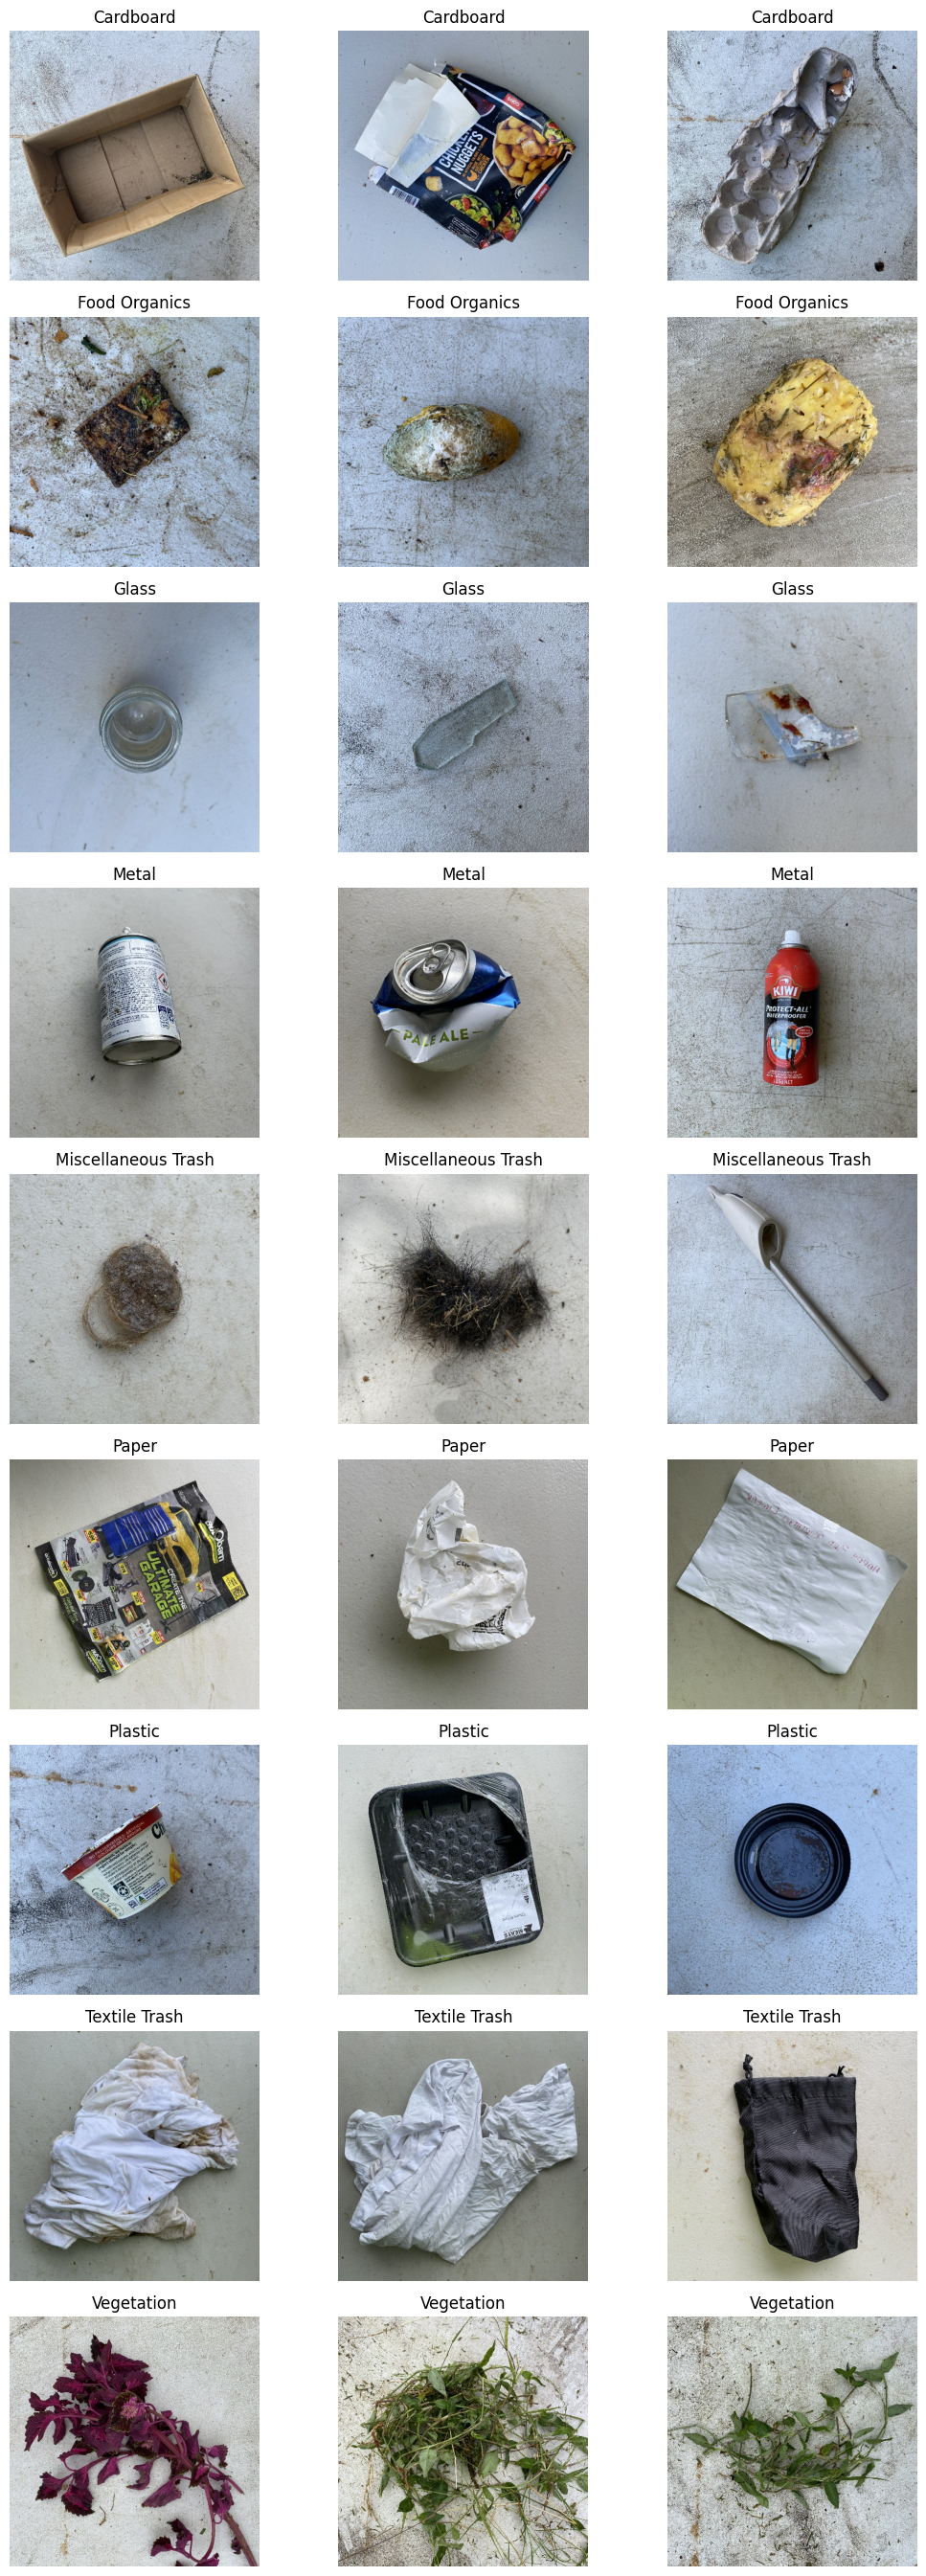

In [7]:
# Visual sample grid: up to 3 valid images per class
classes = sorted(df_meta['class_name'].unique())
fig, axes = plt.subplots(
    len(classes), 3,
    figsize=(11, max(3, 3 * len(classes)))
)

if len(classes) == 1:
    axes = np.array([axes])

for row, cls in enumerate(classes):
    subset = df_meta[df_meta['class_name'] == cls]
    sample_rows = subset.sample(n=min(3, len(subset)), random_state=SEED)

    for col in range(3):
        ax = axes[row, col]
        ax.axis('off')

        if col < len(sample_rows):
            fp = Path(sample_rows.iloc[col]['filepath'])
            with Image.open(fp) as img:
                ax.imshow(img.convert('RGB'))
            ax.set_title(cls)

plt.tight_layout()
plt.savefig(AUDIT_OUT / 'sample_grid.png', dpi=160, bbox_inches='tight')
plt.show()


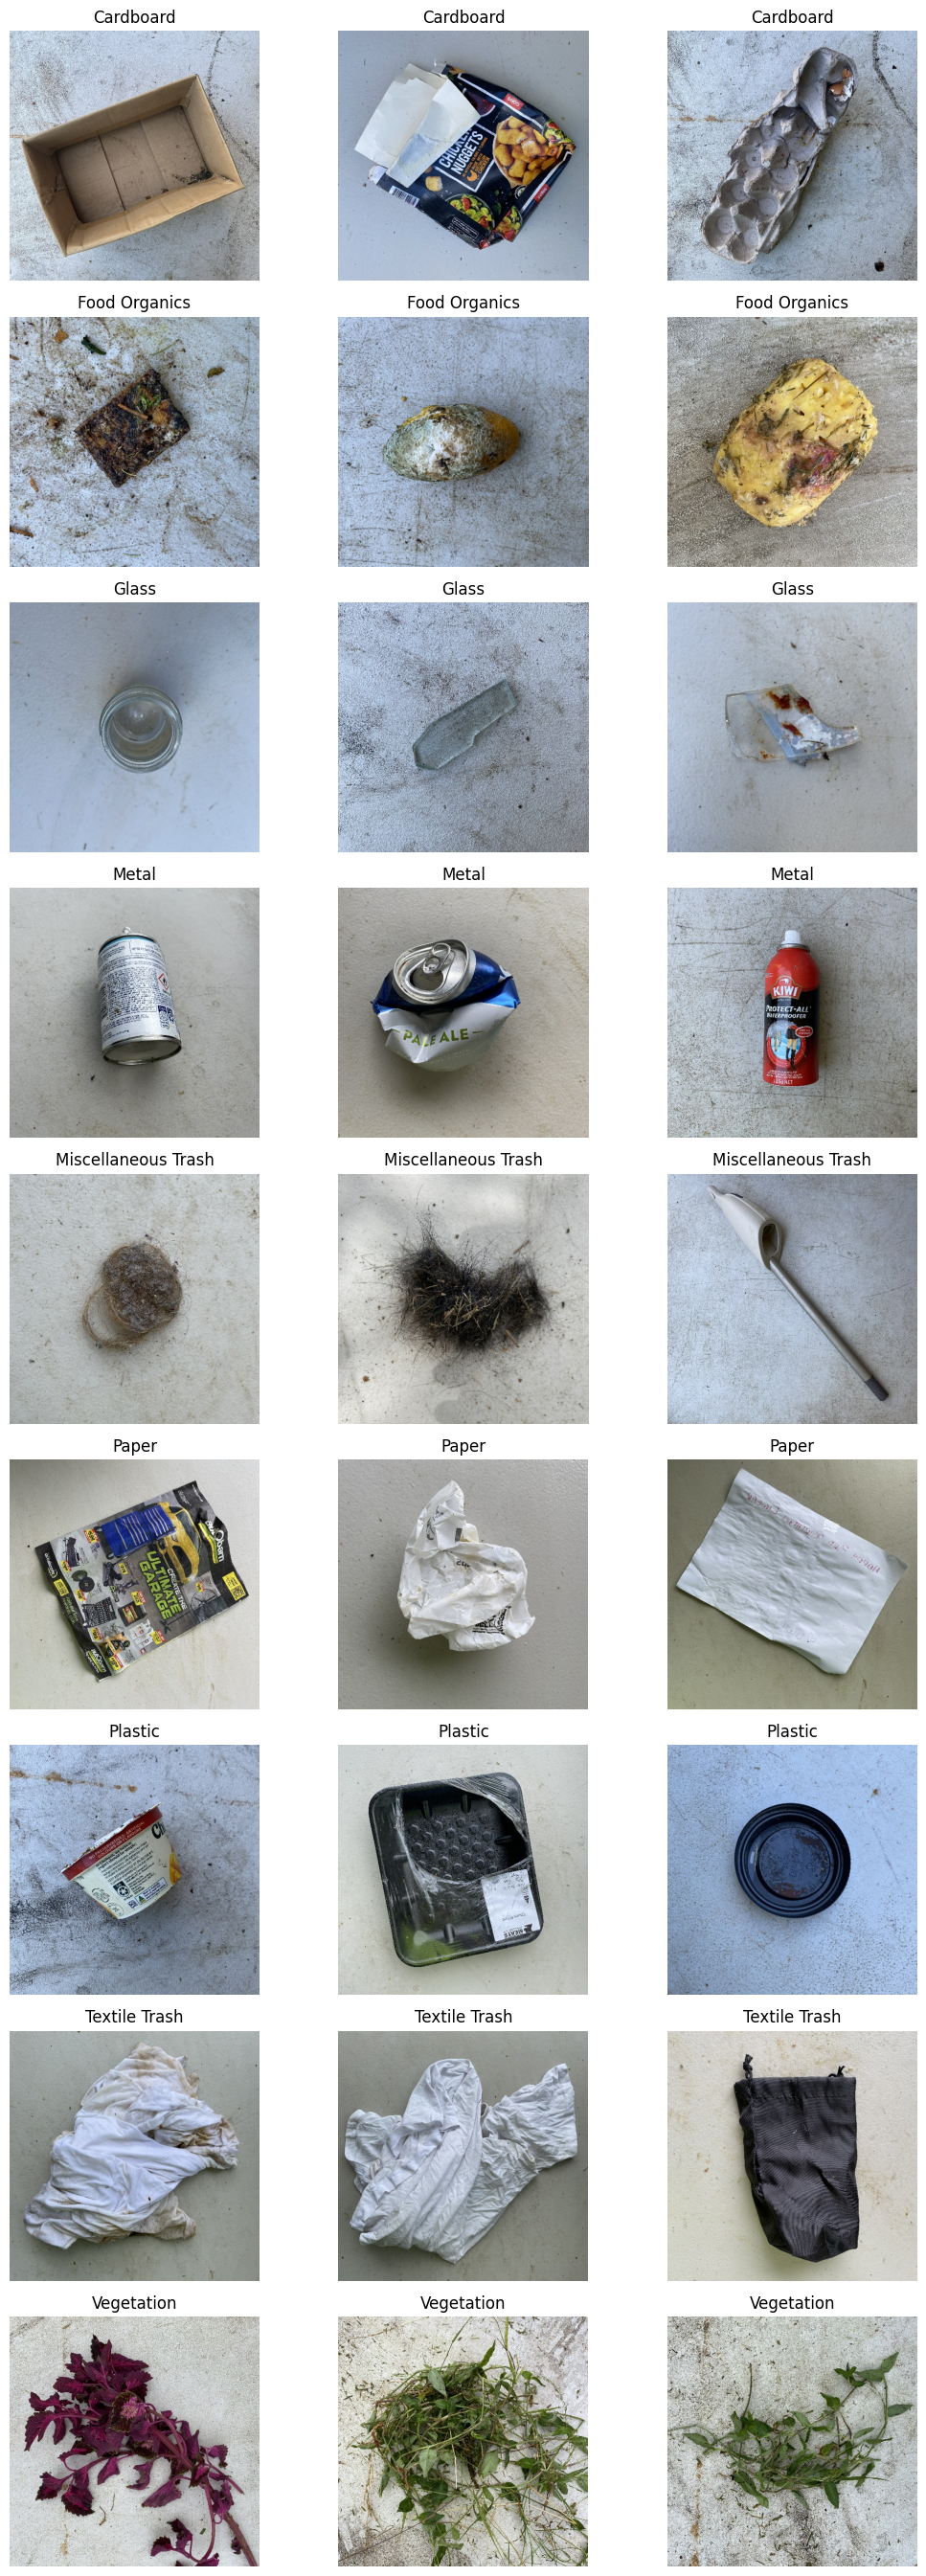

In [8]:
# Visual sample grid: up to 3 valid images per class
classes = sorted(df_meta['class_name'].unique())
fig, axes = plt.subplots(len(classes), 3, figsize=(11, max(3, 3*len(classes))))
if len(classes) == 1:
    axes = np.array([axes])

for row, cls in enumerate(classes):
    subset = df_meta[df_meta['class_name'] == cls]
    sample_rows = subset.sample(n=min(3, len(subset)), random_state=SEED)
    for col in range(3):
        ax = axes[row, col]
        ax.axis('off')
        if col < len(sample_rows):
            fp = Path(sample_rows.iloc[col]['filepath'])
            with Image.open(fp) as img:
                ax.imshow(img.convert('RGB'))
            ax.set_title(cls)

plt.tight_layout()
plt.savefig(AUDIT_OUT/'sample_grid.png', dpi=160, bbox_inches='tight')
plt.show()


## Manual audit notes
Inspect the sample grid and record:
- background complexity;
- mixed materials / ambiguous labels;
- occlusion;
- visually confusing class pairs;
- obvious near-duplicates or burst sequences;
- any strange folders/files.

Send the exact audit outputs to ChatGPT for Gate 1 PASS/FIX. **Do not create split.csv until Gate 1 passes.**
